# Review-informed climate comment clustering (09c)

This notebook turns the completed semantic audit into an operational revision of Notebook 09 while leaving Notebooks 08, 09, and 09b unchanged.

It makes four changes:

1. The old rule status is retained as a diagnostic instead of a hard deletion decision.
2. Reviewed comments train a lightweight relevance gate; reviewed positives are preserved explicitly.
3. Long comments use head-and-tail coverage, while post context is embedded separately at lower weight.
4. MiniLM K-means is the primary topic interpretation; TF-IDF+LSA remains a sensitivity baseline.

All topic labels remain provisional until representative and random comments are inspected.


## 1. Setup / 设置

Fix the data path, research scope, sampling controls and random seed. The six communities and the date range are kept consistent with the earlier RQ1/RQ2 design.

固定数据路径、研究范围、抽样控制和随机种子。六个社区及时间范围与之前的 RQ1/RQ2 设计保持一致。

In [1]:
import importlib.util
import hashlib
import html
import json
import os
import platform
import re
import subprocess
import sys
import time
import warnings
from pathlib import Path

BASE_DIR = Path(r"D:\DM1_project")
os.environ["NUMBA_CACHE_DIR"] = str(BASE_DIR / "outputs" / "numba_cache")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))

REQUIRED_PACKAGES = {
    "pyarrow": "pyarrow",
    "sentence_transformers": "sentence-transformers",
    "umap": "umap-learn",
    "hdbscan": "hdbscan",
}
missing_packages = [package for module, package in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    raise RuntimeError(f"Install missing packages before running Notebook 09c: {missing_packages}")

import hdbscan
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import seaborn as sns
import sklearn
import torch
from IPython.display import display
from scipy import sparse
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import adjusted_rand_score, confusion_matrix, precision_recall_fscore_support, silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import Normalizer, normalize

import transformers.utils as transformers_utils
import transformers.utils.import_utils as transformers_import_utils
for optional_check in [
    "is_torchvision_available", "is_torchvision_v2_available",
    "is_torchaudio_available", "is_vision_available",
]:
    setattr(transformers_import_utils, optional_check, lambda: False)
    setattr(transformers_utils, optional_check, lambda: False)
from sentence_transformers import SentenceTransformer
import umap

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 120

DATA_PATH = BASE_DIR / "distillation_v2_output" / "reddit_climate_cluster_ready_v2.parquet"
REVIEW_PATH = BASE_DIR / "outputs" / "review_09_astra_20261002" / "blind150_review_detail.csv"
OUTPUT_DIR = BASE_DIR / "v2_clustering_outputs_09c_review_informed"
CACHE_DIR = OUTPUT_DIR / "cache"
SELECTED_SUBREDDITS = [
    "climatechange", "climate", "energy",
    "Futurology", "conspiracy", "changemyview",
]
START_DATE = pd.Timestamp("2023-11-19")
END_EXCLUSIVE = pd.Timestamp("2026-09-01")
MIN_WORDS = 20
MAX_COMMENTS_PER_POST = 100
MAX_COMMENTS_PER_AUTHOR = 200
# Match the completed 09 run (4,705 per community; 28,230 total) so the revision
# changes the gate and text representation without adding a sample-size confound.
MAX_TRAIN_PER_SUBREDDIT = 4_705
RANDOM_STATE = 42
K_VALUES = list(range(4, 21))
PRIMARY_K = 12
REVIEW_K_VALUES = [8, 12, 15, 17, 20]
LSA_COMPONENTS = 100
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_BATCH_SIZE = 128
COMMENT_EMBEDDING_WEIGHT = 0.85
CONTEXT_EMBEDDING_WEIGHT = 0.15
COMMENT_HEAD_TOKENS = 112
COMMENT_TAIL_TOKENS = 112
TITLE_TOKENS = 64
BODY_TOKENS = 160
GATE_BATCH_SIZE = 20_000
UMAP_COMPONENTS = 10
UMAP_NEIGHBORS = 30
HDBSCAN_SETTINGS = [
    {"min_cluster_size": 150, "min_samples": 10},
    {"min_cluster_size": 300, "min_samples": 10},
    {"min_cluster_size": 300, "min_samples": 30},
    {"min_cluster_size": 600, "min_samples": 30},
]

assert DATA_PATH.exists(), f"Input file not found: {DATA_PATH}"
assert REVIEW_PATH.exists(), f"Review file not found: {REVIEW_PATH}"
assert PRIMARY_K in K_VALUES
assert abs(COMMENT_EMBEDDING_WEIGHT + CONTEXT_EMBEDDING_WEIGHT - 1.0) < 1e-9
print("Input:", DATA_PATH)
print("Review labels:", REVIEW_PATH)
print("Output:", OUTPUT_DIR)
print("K search:", K_VALUES[0], "to", K_VALUES[-1], "; provisional matched k:", PRIMARY_K)
print("Communities:", ", ".join(SELECTED_SUBREDDITS))
print("Time window:", START_DATE.date(), "to", (END_EXCLUSIVE - pd.Timedelta(days=1)).date())
print("Python:", platform.python_version(), "scikit-learn:", sklearn.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


D:\python 3.13.7\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input: D:\DM1_project\distillation_v2_output\reddit_climate_cluster_ready_v2.parquet
Review labels: D:\DM1_project\outputs\review_09_astra_20261002\blind150_review_detail.csv
Output: D:\DM1_project\v2_clustering_outputs_09c_review_informed
K search: 4 to 20 ; provisional matched k: 12
Communities: climatechange, climate, energy, Futurology, conspiracy, changemyview
Time window: 2023-11-19 to 2026-08-31
Python: 3.13.7 scikit-learn: 1.7.2
Device: cpu


The printed paths and scope should match the project design. Changing a setting here changes the experiment, so record it in the final report.

输出路径和研究范围应与项目设计一致。这里的任何设置变化都会改变实验，因此最终报告需要记录这些设置。

## 2. Load the Notebook 08 main sample / 读取 08 主样本

The relevance selection remains unchanged. This notebook restricts it to six communities, the study dates, and comments with at least 20 words for topic modeling. Excluded or pending Notebook 08 comments do not silently enter the topic sample.
The next gate is stricter than 08 and serves topic modeling only. Its `topic_review` and `topic_exclude` records are not automatically irrelevant for stance analysis.


In [2]:
USE_COLUMNS = [
    "comment_id", "clean_text", "subreddit", "created_time", "post_id",
    "post_title", "post_self_text", "model_text", "author_name", "score", "controversiality",
    "comment_word_count", "post_score", "post_upvote_ratio",
    "direct_comment", "supported_context", "context_only", "cluster_ready_v2", "selection_logic_version", "selection_tier_v2",
    "matched_comment_term_v2", "matched_title_term_v2", "matched_post_body_term_v2",
]

dataset = ds.dataset(DATA_PATH, format="parquet")
filter_expression = (
    ds.field("subreddit").isin(SELECTED_SUBREDDITS)
    & (ds.field("created_time") >= START_DATE.to_pydatetime())
    & (ds.field("created_time") < END_EXCLUSIVE.to_pydatetime())
    & (ds.field("comment_word_count") >= MIN_WORDS)
)

analysis_df = dataset.to_table(columns=USE_COLUMNS, filter=filter_expression).to_pandas()
analysis_df = analysis_df.dropna(subset=["comment_id", "clean_text", "post_id", "subreddit"]).copy()
analysis_df = analysis_df.drop_duplicates(subset="comment_id", keep="first")
analysis_df["clean_text"] = analysis_df["clean_text"].astype(str).str.strip()
analysis_df["post_title"] = analysis_df["post_title"].fillna("").astype(str).str.strip()
analysis_df = analysis_df.loc[analysis_df["clean_text"].ne("")].reset_index(drop=True)

assert analysis_df["cluster_ready_v2"].all(), "Input contains records outside Notebook 08's main sample."
assert analysis_df["selection_logic_version"].eq("combined_context_tiered_review_v1").all(), "Input was built by a different Notebook 08 rule."
assert analysis_df["comment_id"].is_unique
analysis_df["model_text"] = analysis_df["model_text"].fillna("").astype(str)
assert analysis_df["model_text"].str.startswith("[POST TITLE] ").all()
assert analysis_df["model_text"].str.contains("\n[POST BODY] ", regex=False).all()
assert analysis_df["model_text"].str.contains("\n[COMMENT] ", regex=False).all()
# Use Notebook 08's saved full context. Do not rebuild it from partial columns.

scope_audit = (
    analysis_df.groupby(["subreddit", "selection_tier_v2"], observed=True)
    .size().unstack(fill_value=0).reindex(SELECTED_SUBREDDITS, fill_value=0)
)
scope_audit["total"] = scope_audit.sum(axis=1)
display(scope_audit)
print("Eligible strict comments:", f"{len(analysis_df):,}")
print("Unique posts:", f"{analysis_df['post_id'].nunique():,}")
print("Unique authors:", f"{analysis_df['author_name'].nunique():,}")
print("Dates:", analysis_df["created_time"].min(), "to", analysis_df["created_time"].max())

selection_tier_v2,adjacent_review,context_only,direct_comment,not_selected,supported_context,total
subreddit,,,,,,
climatechange,2,0,55319,0,21497,76818
climate,1,0,33170,0,12711,45882
energy,1,2,22172,1,14822,36998
Futurology,0,0,16276,0,10646,26922
conspiracy,0,0,6675,0,3256,9931
changemyview,0,2,9719,0,6078,15799


Eligible strict comments: 212,350
Unique posts: 17,869
Unique authors: 58,103
Dates: 2023-11-19 00:00:25 to 2026-08-31 23:16:36


## 3. Review-informed topic gate / 基于复核的主题门槛

The previous regular-expression status is preserved for diagnosis. It is no longer used as a deletion rule because the semantic audit found substantial false negatives in both `topic_review` and `topic_exclude`.

A small word-and-character TF-IDF classifier is trained from the 150 reviewed rows. Cross-validated probabilities choose a recall-oriented threshold. Operational inclusion is the union of:

- the old high-precision `topic_ready` group;
- comments exceeding the review-informed score threshold; and
- reviewed comments already judged relevant.

The labels are model-assisted review labels, not an independent human gold standard. Gate diagnostics must therefore be reported with that limitation.


In [3]:
from outputs.topic_readiness_filter import classify_topic_readiness

readiness_df = classify_topic_readiness(analysis_df)
assert readiness_df.index.equals(analysis_df.index)
analysis_df = pd.concat([analysis_df, readiness_df], axis=1)

def head_tail_chars(value, max_chars=2400):
    value = "" if pd.isna(value) else " ".join(str(value).split())
    if len(value) <= max_chars:
        return value
    half = max_chars // 2
    return value[:half] + " ... " + value[-half:]

def build_gate_text(frame):
    comment = frame["clean_text"].map(lambda x: head_tail_chars(x, 3000))
    title = frame["post_title"].map(lambda x: head_tail_chars(x, 500))
    body = frame["post_self_text"].fillna("").map(lambda x: head_tail_chars(x, 1200))
    return "[COMMENT] " + comment + " [TITLE] " + title + " [POST] " + body

audit_df = pd.read_csv(REVIEW_PATH, encoding="utf-8-sig")
audit_train_df = audit_df.loc[audit_df["relevance_final"].ne("uncertain")].copy()
audit_train_df["target"] = audit_train_df["relevance_final"].isin(["relevant", "contextual_relevant"]).astype(int)
audit_train_df["gate_text"] = build_gate_text(audit_train_df.rename(columns={
    "comment": "clean_text", "title": "post_title"
}))

gate_features = FeatureUnion([
    ("word", TfidfVectorizer(
        lowercase=True, stop_words=sorted(ENGLISH_STOP_WORDS), ngram_range=(1, 2),
        min_df=2, max_df=0.98, max_features=30_000, sublinear_tf=True,
    )),
    ("char", TfidfVectorizer(
        lowercase=True, analyzer="char_wb", ngram_range=(3, 5),
        min_df=2, max_features=30_000, sublinear_tf=True,
    )),
])
gate_pipeline = Pipeline([
    ("features", gate_features),
    ("classifier", LogisticRegression(
        C=2.0, class_weight="balanced", max_iter=2000,
        random_state=RANDOM_STATE, solver="liblinear",
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_probability = cross_val_predict(
    gate_pipeline, audit_train_df["gate_text"], audit_train_df["target"],
    cv=cv, method="predict_proba", n_jobs=1,
)[:, 1]

threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 181):
    prediction = (cv_probability >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        audit_train_df["target"], prediction, average="binary", zero_division=0,
    )
    threshold_rows.append({
        "threshold": threshold, "precision": precision, "recall": recall, "f1": f1,
        "predicted_positive": int(prediction.sum()),
    })
gate_threshold_curve_df = pd.DataFrame(threshold_rows)
eligible_thresholds = gate_threshold_curve_df.loc[gate_threshold_curve_df["recall"].ge(0.90)]
if len(eligible_thresholds):
    selected_threshold_row = eligible_thresholds.sort_values(
        ["precision", "f1", "threshold"], ascending=[False, False, False]
    ).iloc[0]
else:
    selected_threshold_row = gate_threshold_curve_df.sort_values(
        ["recall", "precision", "f1"], ascending=False
    ).iloc[0]
GATE_THRESHOLD = float(selected_threshold_row["threshold"])
audit_train_df["cv_probability"] = cv_probability
audit_train_df["cv_prediction"] = (cv_probability >= GATE_THRESHOLD).astype(int)
gate_cv_confusion = confusion_matrix(audit_train_df["target"], audit_train_df["cv_prediction"], labels=[0, 1])
gate_cv_metrics_df = pd.DataFrame([{
    "review_rows_used": len(audit_train_df),
    "review_positive": int(audit_train_df["target"].sum()),
    "review_negative": int((1 - audit_train_df["target"]).sum()),
    "threshold": GATE_THRESHOLD,
    "precision": float(selected_threshold_row["precision"]),
    "recall": float(selected_threshold_row["recall"]),
    "f1": float(selected_threshold_row["f1"]),
    "true_negative": int(gate_cv_confusion[0, 0]),
    "false_positive": int(gate_cv_confusion[0, 1]),
    "false_negative": int(gate_cv_confusion[1, 0]),
    "true_positive": int(gate_cv_confusion[1, 1]),
}])

gate_pipeline.fit(audit_train_df["gate_text"], audit_train_df["target"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
gate_fingerprint = hashlib.sha256(REVIEW_PATH.read_bytes())
gate_fingerprint.update(sklearn.__version__.encode("utf-8"))
for comment_id in analysis_df["comment_id"]:
    gate_fingerprint.update(str(comment_id).encode("utf-8"))
    gate_fingerprint.update(b"\0")
gate_score_path = CACHE_DIR / f"review_gate_scores_{gate_fingerprint.hexdigest()[:20]}.npy"
if gate_score_path.exists():
    gate_scores = np.load(gate_score_path)
    assert len(gate_scores) == len(analysis_df)
    print("Loaded cached review-gate scores:", gate_score_path)
else:
    analysis_gate_text = build_gate_text(analysis_df)
    gate_scores = np.empty(len(analysis_df), dtype=np.float32)
    for start in range(0, len(analysis_df), GATE_BATCH_SIZE):
        stop = min(start + GATE_BATCH_SIZE, len(analysis_df))
        gate_scores[start:stop] = gate_pipeline.predict_proba(analysis_gate_text.iloc[start:stop])[:, 1]
    np.save(gate_score_path, gate_scores)
analysis_df["review_gate_score"] = gate_scores
review_positive_ids = set(audit_df.loc[audit_df["on_topic_final"].astype(str).str.lower().eq("true"), "comment_id"])
analysis_df["reviewed_positive_override"] = analysis_df["comment_id"].isin(review_positive_ids)
analysis_df["review_informed_keep"] = (
    analysis_df["topic_readiness"].eq("topic_ready")
    | analysis_df["review_gate_score"].ge(GATE_THRESHOLD)
    | analysis_df["reviewed_positive_override"]
)
candidate_df = analysis_df.loc[analysis_df["review_informed_keep"]].copy()

readiness_counts_df = (
    analysis_df.groupby([
        "subreddit", "selection_tier_v2", "topic_readiness",
        "topic_readiness_reason", "review_informed_keep",
    ], observed=True).size().rename("comments").reset_index()
)
readiness_summary = pd.crosstab(
    [analysis_df["subreddit"], analysis_df["topic_readiness"]],
    analysis_df["review_informed_keep"],
).rename(columns={False: "held_out", True: "kept"})

assert len(candidate_df) > 0
assert candidate_df["comment_id"].is_unique
display(gate_cv_metrics_df.round(4))
display(readiness_summary)
print("09-eligible 08 comments:", f"{len(analysis_df):,}")
print("Old topic-ready seed:", f"{analysis_df['topic_readiness'].eq('topic_ready').sum():,}")
print("Review-informed candidates:", f"{len(candidate_df):,}")
print("Selected CV threshold:", round(GATE_THRESHOLD, 3))


Loaded cached review-gate scores: D:\DM1_project\v2_clustering_outputs_09c_review_informed\cache\review_gate_scores_1d036dc2e09170855ffd.npy


,review_rows_used,review_positive,review_negative,threshold,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,148,128,20,0.655,0.8923,0.9062,0.8992,6,14,12,116


review_informed_keep           held_out   kept
subreddit     topic_readiness                 
Futurology    topic_exclude         835   2432
              topic_ready             0  14316
              topic_review         1249   8090
changemyview  topic_exclude        2714   1036
              topic_ready             0   8063
              topic_review         1919   2067
climate       topic_exclude         947   7851
              topic_ready             0  23919
              topic_review         1218  11947
climatechange topic_exclude        1165   7606
              topic_ready             0  45405
              topic_review         3308  19334
conspiracy    topic_exclude         711   1382
              topic_ready             0   4716
              topic_review          712   2410
energy        topic_exclude         188   3609
              topic_ready             0  19211
              topic_review          494  13496

09-eligible 08 comments: 212,350
Old topic-ready seed: 115,630
Review-informed candidates: 196,890
Selected CV threshold: 0.655


The rule status, classifier score, and final operational decision are all retained. A comment that is held out here is not relabeled as irrelevant in Notebook 08; the decision applies only to the clustering experiment.


## 4. Balanced sample and structured text representation / 平衡抽样与结构化文本表示

Apply the same duplicate, post, author, and community controls as Notebook 09. For MiniLM, encode the comment and its post context separately. Long comments retain both their beginning and conclusion. The final semantic vector gives 85% weight to the comment and 15% to the title/body context.

The baseline uses the same comment/context split with separate TF-IDF blocks, so the comparison no longer depends on one shared 230-token concatenation.


In [4]:
rng = np.random.default_rng(RANDOM_STATE)
controlled_df = candidate_df.drop_duplicates(subset=["subreddit", "model_text"], keep="first").copy()
controlled_df["_order"] = rng.random(len(controlled_df))
controlled_df = controlled_df.sort_values("_order")
controlled_df = controlled_df.groupby("post_id", sort=False, group_keys=False).head(MAX_COMMENTS_PER_POST)
controlled_df = (
    controlled_df.groupby("author_name", sort=False, group_keys=False, dropna=False)
    .head(MAX_COMMENTS_PER_AUTHOR).drop(columns="_order").reset_index(drop=True)
)
available = controlled_df.groupby("subreddit").size().reindex(SELECTED_SUBREDDITS)
TRAIN_PER_SUBREDDIT = int(min(MAX_TRAIN_PER_SUBREDDIT, available.min()))
assert TRAIN_PER_SUBREDDIT > 0
parts = [
    controlled_df.loc[controlled_df["subreddit"].eq(community)]
    .sample(n=TRAIN_PER_SUBREDDIT, random_state=RANDOM_STATE)
    for community in SELECTED_SUBREDDITS
]
model_df = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
sentence_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=device, local_files_only=True)
tokenizer = sentence_model.tokenizer
max_model_tokens = sentence_model.max_seq_length
assert max_model_tokens >= 248, f"Unexpected model window: {max_model_tokens}"

def clean_topic_field(value):
    if pd.isna(value):
        return ""
    value = html.unescape(str(value))
    value = value.translate(str.maketrans({
        "’": "'", "‘": "'", "“": '"', "”": '"',
        "—": "-", "–": "-", "\ufffd": " ",
    }))
    value = re.sub(r"\[([^\]]+)\]\((?:https?://|www\.)[^)]+\)", r"\1", value)
    value = re.sub(r"(?i)(?:https?://|www\.)[^\s<>]*", " ", value)
    value = re.sub(r"(?s)```.*?```", " ", value)
    value = re.sub(r"</?[A-Za-z][^>]{0,150}>", " ", value)
    value = re.sub(r"(?m)^\s{0,3}(?:[#>*-]+\s+)", "", value)
    value = re.sub(r"(?i)\b(?:amp|nbsp)\b", " ", value)
    return " ".join(value.split())

def token_slice(value, start=None, stop=None):
    ids = tokenizer(value, add_special_tokens=False, truncation=False, verbose=False)["input_ids"]
    chosen = ids[slice(start, stop)]
    return tokenizer.decode(chosen, skip_special_tokens=True).strip(), len(ids)

comment_full_texts, comment_head_texts, comment_tail_texts = [], [], []
context_texts, title_texts, body_texts = [], [], []
comment_token_counts, context_token_counts, comment_truncated = [], [], []

for row in model_df[["clean_text", "post_title", "post_self_text"]].itertuples(index=False):
    comment_full = clean_topic_field(row.clean_text)
    title_full = clean_topic_field(row.post_title)
    body_full = clean_topic_field(row.post_self_text)
    head, n_comment_tokens = token_slice(comment_full, 0, COMMENT_HEAD_TOKENS)
    tail = ""
    if n_comment_tokens > COMMENT_HEAD_TOKENS:
        tail, _ = token_slice(comment_full, -COMMENT_TAIL_TOKENS, None)
    title, _ = token_slice(title_full, 0, TITLE_TOKENS)
    body, _ = token_slice(body_full, 0, BODY_TOKENS)
    context = " . ".join(part for part in [title, body] if part)
    context_ids = tokenizer.encode(context, add_special_tokens=False, truncation=True, max_length=max_model_tokens - 2)
    context = tokenizer.decode(context_ids, skip_special_tokens=True).strip()

    comment_full_texts.append(comment_full)
    comment_head_texts.append(head)
    comment_tail_texts.append(tail)
    title_texts.append(title)
    body_texts.append(body)
    context_texts.append(context)
    comment_token_counts.append(n_comment_tokens)
    context_token_counts.append(len(context_ids) + 2)
    comment_truncated.append(bool(tail))

model_df["topic_comment_text"] = comment_full_texts
model_df["comment_head_text"] = comment_head_texts
model_df["comment_tail_text"] = comment_tail_texts
model_df["comment_representation_text"] = [
    " ... ".join(part for part in [head, tail] if part)
    for head, tail in zip(comment_head_texts, comment_tail_texts)
]
model_df["topic_title_text"] = title_texts
model_df["topic_body_text"] = body_texts
model_df["topic_context_text"] = context_texts
model_df["topic_text"] = [
    "[COMMENT] " + comment + (" [CONTEXT] " + context if context else "")
    for comment, context in zip(model_df["comment_representation_text"], context_texts)
]
model_df["comment_token_count"] = comment_token_counts
model_df["context_token_count"] = context_token_counts
model_df["comment_head_tail_used"] = comment_truncated

assert model_df["comment_representation_text"].str.len().gt(0).all()
assert model_df["context_token_count"].le(max_model_tokens).all()
bad_urls = model_df["topic_text"].str.contains(r"https?://|www\.", regex=True, case=False)
assert not bad_urls.any(), model_df.loc[bad_urls, ["comment_id", "topic_text"]].head(5).to_dict("records")

sample_audit = model_df.groupby("subreddit").agg(
    comments=("comment_id", "size"), posts=("post_id", "nunique"),
    authors=("author_name", "nunique"), direct_share=("direct_comment", "mean"),
    median_words=("comment_word_count", "median"),
).reindex(SELECTED_SUBREDDITS)

case_groups = {
    "long_comment": model_df["comment_head_tail_used"],
    "long_post_body": model_df["post_self_text"].fillna("").str.len().gt(1200),
    "ordinary": pd.Series(True, index=model_df.index),
}
cleanup_cases = []
seen_ids = set()
for issue, mask in case_groups.items():
    candidates = model_df.loc[mask].sample(frac=1, random_state=RANDOM_STATE)
    for row in candidates.itertuples(index=False):
        if row.comment_id in seen_ids:
            continue
        cleanup_cases.append({
            "issue": issue, "comment_id": row.comment_id, "subreddit": row.subreddit,
            "full_comment": row.topic_comment_text,
            "comment_representation": row.comment_representation_text,
            "context_representation": row.topic_context_text,
            "post_title": row.post_title,
            "comment_tokens": row.comment_token_count,
            "head_tail_used": row.comment_head_tail_used,
        })
        seen_ids.add(row.comment_id)
        if sum(case["issue"] == issue for case in cleanup_cases) >= 4:
            break
cleanup_audit_df = pd.DataFrame(cleanup_cases)
topic_text_quality_df = pd.DataFrame([{
    "modeling_comments": len(model_df),
    "empty_comment_representations": int(model_df["comment_representation_text"].eq("").sum()),
    "duplicate_topic_texts": int(model_df["topic_text"].duplicated().sum()),
    "head_tail_comments": int(model_df["comment_head_tail_used"].sum()),
    "max_full_comment_tokens": int(model_df["comment_token_count"].max()),
    "max_context_tokens": int(model_df["context_token_count"].max()),
    "comment_weight": COMMENT_EMBEDDING_WEIGHT,
    "context_weight": CONTEXT_EMBEDDING_WEIGHT,
}])

display(sample_audit)
display(cleanup_audit_df[[
    "issue", "comment_id", "full_comment", "comment_representation", "context_representation"
]].assign(
    full_comment=lambda x: x["full_comment"].str.slice(0, 180),
    comment_representation=lambda x: x["comment_representation"].str.slice(0, 180),
    context_representation=lambda x: x["context_representation"].str.slice(0, 180),
))
display(topic_text_quality_df)
print("Before controls (review-informed):", f"{len(candidate_df):,}")
print("After duplicate/post/author controls:", f"{len(controlled_df):,}")
print("Per community:", f"{TRAIN_PER_SUBREDDIT:,}")
print("Common modeling sample:", f"{len(model_df):,}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20291.84it/s]

,comments,posts,authors,direct_share,median_words
subreddit,,,,,
climatechange,4705,1960,3063,0.732837,57.0
climate,4705,2419,2861,0.738789,52.0
energy,4705,1377,3132,0.602976,49.0
Futurology,4705,813,3341,0.633794,59.0
conspiracy,4705,967,2753,0.729862,53.0
changemyview,4705,651,2740,0.755579,89.0


,issue,comment_id,full_comment,comment_representation,context_representation
0,long_comment,p1r1upp,If you're really experiencing that many public...,if you ' re really experiencing that many publ...,fact brief : do solar plants require backup fr...
1,long_comment,kqr5ttj,"But all ""liberals"" care about, like George Car...","but all "" liberals "" care about, like george c...",""" green energy "" means modern day slavery in t..."
2,long_comment,np3hoo9,Where do you think everyone spends most of the...,where do you think everyone spends most of the...,"cmv : as a society, we are closest to dystopia..."
3,long_comment,ktn6cxp,Yes. There were a lot of plans to move towards...,yes. there were a lot of plans to move towards...,"exxonmobil ' s ceo, the head of america ' s la..."
4,long_post_body,nuk22ss,if you're really worried about climate change ...,if you ' re really worried about climate chang...,the cover - up of human caused climate change ...
5,long_post_body,kfvchxp,>This does not include arguing out that the ex...,> this does not include arguing out that the e...,"cmv : the category of "" expert "", as such, sho..."
6,long_post_body,kg1gv70,Nuclear is the worst complement to renewables ...,nuclear is the worst complement to renewables ...,will the united states reach net zero greenhou...
7,long_post_body,l3gol8z,This points at a bigger flaw in the construct ...,this points at a bigger flaw in the construct ...,reminder that there is no climate crisis. raw ...
8,ordinary,p2a5glx,"Well, except for Germany who decommissioned al...","well, except for germany who decommissioned al...",china drives global nuclear power generation t...
9,ordinary,kbtmrsb,You can see the climate change for yourself an...,you can see the climate change for yourself an...,c1imate change is a h0ax?. statistics tells us...


,modeling_comments,empty_comment_representations,duplicate_topic_texts,head_tail_comments,max_full_comment_tokens,max_context_tokens,comment_weight,context_weight
0,28230,0,2,8454,2048,227,0.85,0.15


Before controls (review-informed): 196,890
After duplicate/post/author controls: 180,016
Per community: 4,705
Common modeling sample: 28,230


All six communities should have the same number of modeling comments. The post and author counts confirm that the sample is not coming from only a few sources.

六个社区的建模评论数应当相同。帖子数和作者数用于确认样本并非只来自少量来源。

## 5. Baseline: separate comment and context TF-IDF blocks / 基线文本表示

The baseline receives the same structural distinction as the semantic model. Comment and post-context TF-IDF blocks are normalized separately, weighted 85/15, concatenated, and then reduced with 100-dimensional LSA.


In [5]:
custom_stop_words = sorted(set(ENGLISH_STOP_WORDS) - {"no", "not", "nor", "never"})
comment_vectorizer = TfidfVectorizer(
    lowercase=True, stop_words=custom_stop_words, ngram_range=(1, 2),
    min_df=10, max_df=0.85, max_features=40_000,
    sublinear_tf=True, norm="l2", dtype=np.float32,
)
context_vectorizer = TfidfVectorizer(
    lowercase=True, stop_words=custom_stop_words, ngram_range=(1, 2),
    min_df=10, max_df=0.90, max_features=20_000,
    sublinear_tf=True, norm="l2", dtype=np.float32,
)
t0 = time.perf_counter()
X_comment_tfidf = comment_vectorizer.fit_transform(model_df["comment_representation_text"])
X_context_tfidf = context_vectorizer.fit_transform(model_df["topic_context_text"])
X_tfidf = sparse.hstack([
    X_comment_tfidf * COMMENT_EMBEDDING_WEIGHT,
    X_context_tfidf * CONTEXT_EMBEDDING_WEIGHT,
], format="csr", dtype=np.float32)
X_tfidf = normalize(X_tfidf, norm="l2", copy=False)
lsa = TruncatedSVD(n_components=LSA_COMPONENTS, random_state=RANDOM_STATE)
lsa_normalizer = Normalizer(copy=False)
X_lsa = lsa_normalizer.fit_transform(lsa.fit_transform(X_tfidf)).astype(np.float32)
print("Comment TF-IDF shape:", X_comment_tfidf.shape)
print("Context TF-IDF shape:", X_context_tfidf.shape)
print("Combined TF-IDF shape:", X_tfidf.shape)
print("LSA shape:", X_lsa.shape)
print("LSA explained variance:", f"{lsa.explained_variance_ratio_.sum():.2%}")
print("Feature time:", f"{time.perf_counter() - t0:.1f} seconds")


Comment TF-IDF shape: (28230, 14847)
Context TF-IDF shape: (28230, 20000)
Combined TF-IDF shape: (28230, 34847)
LSA shape: (28230, 100)
LSA explained variance: 10.83%
Feature time: 7.5 seconds


The baseline now distinguishes the comment from its post context. This makes it a stronger comparison than concatenating everything into one token budget, while it remains a lexical/latent-semantic baseline.


## 6. Baseline K-means k=4–20 / 基线聚类

Keep all k-search results. k=12 is the provisional matched comparison so that both representation pipelines can be inspected at identical granularity. The silhouette leader is reported separately; no final topic count is selected without stability and comment review.

In [6]:
baseline_rows = []
baseline_models = {}
baseline_labels_by_k = {}
for k in K_VALUES:
    started = time.perf_counter()
    candidate = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(X_lsa)
    shares = pd.Series(labels).value_counts(normalize=True)
    sil = silhouette_score(X_lsa, labels, metric="cosine", sample_size=min(5000, len(model_df)), random_state=RANDOM_STATE)
    baseline_rows.append({
        "k": k, "silhouette_cosine": sil, "inertia": candidate.inertia_,
        "minimum_cluster_share": shares.min(), "maximum_cluster_share": shares.max(),
        "seconds": time.perf_counter() - started,
    })
    baseline_models[k] = candidate
    baseline_labels_by_k[k] = labels
    print(f"baseline k={k}: silhouette={sil:.4f}")

baseline_search_df = pd.DataFrame(baseline_rows)
baseline_silhouette_leader = int(baseline_search_df.loc[baseline_search_df["silhouette_cosine"].idxmax(), "k"])
BEST_K = PRIMARY_K  # compatibility name; the comparison k is provisional
baseline_model = baseline_models[PRIMARY_K]
baseline_labels = baseline_labels_by_k[PRIMARY_K]
model_df["baseline_cluster"] = baseline_labels
baseline_centers = baseline_model.cluster_centers_ / np.maximum(
    np.linalg.norm(baseline_model.cluster_centers_, axis=1, keepdims=True), 1e-12
)
model_df["baseline_membership_strength"] = np.sum(X_lsa * baseline_centers[baseline_labels], axis=1)
display(baseline_search_df)
print("Provisional matched k:", PRIMARY_K)
print("Baseline silhouette leader (diagnostic only):", baseline_silhouette_leader)

D:\python 3.13.7\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\python 3.13.7\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "D:\python 3.13.7\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "D:\python 3.13.7\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python 3.13.7\Lib\subprocess.py", line 1039

baseline k=4: silhouette=0.0647


baseline k=5: silhouette=0.0717


baseline k=6: silhouette=0.0771


baseline k=7: silhouette=0.0828


...

baseline k=18: silhouette=0.1048


baseline k=19: silhouette=0.1138


baseline k=20: silhouette=0.1123


,k,silhouette_cosine,inertia,minimum_cluster_share,maximum_cluster_share,seconds
0,4,0.064686,23174.060547,0.079844,0.395289,1.413431
1,5,0.071695,22843.351562,0.076727,0.341410,0.647557
2,6,0.077141,22531.771484,0.065143,0.302976,0.730019
3,7,0.082763,22226.595703,0.050549,0.314984,0.694130
4,8,0.085141,21987.617188,0.060468,0.252674,0.722466
5,9,0.088808,21725.052734,0.042650,0.196635,0.811353
6,10,0.096947,21459.751953,0.044810,0.253170,0.817931
7,11,0.097914,21255.423828,0.041162,0.202869,0.899667
8,12,0.101526,21090.304688,0.030677,0.202196,0.889978
9,13,0.103122,20852.205078,0.031243,0.180198,1.050578


Provisional matched k: 12
Baseline silhouette leader (diagnostic only): 19


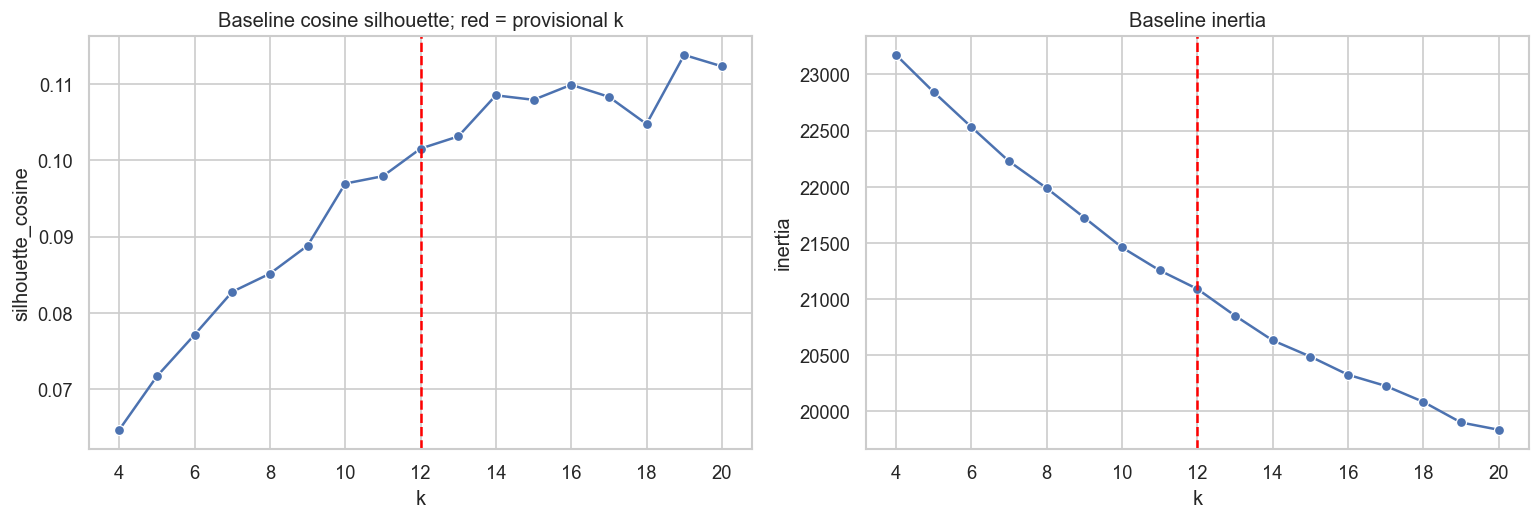

,cluster,size,top_terms
0,0,1503,"co2, emissions, atmosphere, climate, just, yea..."
1,1,2074,"climate, years, weather, temperature, year, he..."
2,2,2466,"solar, wind, energy, power, panels, solar pane..."
3,3,3638,"energy, power, nuclear, coal, just, plants, gr..."
4,4,1698,"oil, gas, energy, companies, just, oil gas, pe..."
5,5,1152,"warming, global, global warming, climate, chan..."
6,6,866,"ice, sea, sea level, level, climate, ice age, ..."
7,7,1615,"carbon, emissions, just, people, climate, like..."
8,8,3893,"climate, change, climate change, people, just,..."
9,9,1906,"fossil, fuels, fossil fuels, fuel, fossil fuel..."


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=baseline_search_df, x="k", y="silhouette_cosine", marker="o", ax=axes[0])
axes[0].axvline(PRIMARY_K, color="red", linestyle="--")
axes[0].set_title("Baseline cosine silhouette; red = provisional k")
sns.lineplot(data=baseline_search_df, x="k", y="inertia", marker="o", ax=axes[1])
axes[1].axvline(PRIMARY_K, color="red", linestyle="--")
axes[1].set_title("Baseline inertia")
plt.tight_layout()
plt.show()

def describe_topics(label_column):
    source = model_df.loc[model_df[label_column].ge(0), [label_column, "topic_comment_text"]]
    documents = source.groupby(label_column)["topic_comment_text"].agg(" ".join).sort_index()
    label_vectorizer = CountVectorizer(
        stop_words=sorted(ENGLISH_STOP_WORDS), ngram_range=(1, 2),
        min_df=1, max_features=50_000,
    )
    counts = label_vectorizer.fit_transform(documents)
    terms = label_vectorizer.get_feature_names_out()
    row_sums = np.asarray(counts.sum(axis=1)).ravel()
    tf = counts.multiply((1 / np.maximum(row_sums, 1))[:, None])
    idf = np.log((1 + counts.shape[0]) / (1 + np.asarray((counts > 0).sum(axis=0)).ravel())) + 1
    c_tfidf = tf.multiply(idf)
    rows = []
    for row_index, cluster_id in enumerate(documents.index):
        scores = c_tfidf.getrow(row_index).toarray().ravel()
        top = np.argsort(scores)[-15:][::-1]
        rows.append({
            "cluster": int(cluster_id),
            "size": int(model_df[label_column].eq(cluster_id).sum()),
            "top_terms": ", ".join(terms[top]),
        })
    return pd.DataFrame(rows).sort_values("cluster")

baseline_terms_df = describe_topics("baseline_cluster")
display(baseline_terms_df)

The displayed terms come from cleaned comment text using the same c-TF-IDF method for both pipelines. They support provisional naming only; inspect representative and random comments before making a final label.

## 7. Baseline seed stability / 基线稳定性

Measure assignment agreement at provisional k=12 across five seeds. Higher silhouette at another k does not automatically override poorer stability or uninterpretable topics.

In [8]:
seed_labels = {}
for seed in [7, 21, 42, 84, 168]:
    m = KMeans(n_clusters=BEST_K, init="k-means++", n_init=10, max_iter=300, random_state=seed)
    seed_labels[seed] = m.fit_predict(X_lsa)

ari_rows = []
seeds = list(seed_labels)
for i, left in enumerate(seeds):
    for right in seeds[i + 1:]:
        ari_rows.append({"seed_a": left, "seed_b": right, "ARI": adjusted_rand_score(seed_labels[left], seed_labels[right])})
baseline_stability_df = pd.DataFrame(ari_rows)
display(baseline_stability_df)
print("Mean ARI:", f"{baseline_stability_df['ARI'].mean():.3f}")

,seed_a,seed_b,ARI
0,7,21,0.727123
1,7,42,0.771277
2,7,84,0.749583
3,7,168,0.728624
4,21,42,0.839244
5,21,84,0.887516
6,21,168,0.984680
7,42,84,0.750239
8,42,168,0.838265
9,84,168,0.884470


Mean ARI: 0.816


ARI close to 1 means the same comments repeatedly group together. Low ARI means the selected k may be unstable even if its silhouette is acceptable.

ARI 越接近 1，说明相同评论会重复聚在一起。若 ARI 较低，即使 silhouette 尚可，所选 k 仍可能不稳定。

## 8. MiniLM semantic representation with comment-first weighting / MiniLM 语义表示

Encode comment heads, comment conclusions, and post context separately. For long comments, average the normalized head and tail vectors. Combine the resulting comment vector with the context vector at 85/15 and normalize again. UMAP remains a separate input only for the HDBSCAN coverage diagnostic.


In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

fingerprint = hashlib.sha256(EMBEDDING_MODEL_NAME.encode("utf-8"))
fingerprint.update(str(COMMENT_EMBEDDING_WEIGHT).encode("utf-8"))
fingerprint.update(str(CONTEXT_EMBEDDING_WEIGHT).encode("utf-8"))
for row in model_df[["comment_id", "comment_head_text", "comment_tail_text", "topic_context_text"]].itertuples(index=False):
    for value in row:
        fingerprint.update(str(value).encode("utf-8"))
        fingerprint.update(b"\0")
embedding_path = CACHE_DIR / f"weighted_embeddings_{fingerprint.hexdigest()[:20]}.npy"

if embedding_path.exists():
    embeddings = np.load(embedding_path)
    assert len(embeddings) == len(model_df)
    print("Loaded cached embeddings:", embedding_path)
else:
    head_embeddings = sentence_model.encode(
        model_df["comment_head_text"].tolist(), batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
    ).astype(np.float32)
    comment_embeddings = head_embeddings.copy()
    tail_mask = model_df["comment_tail_text"].ne("").to_numpy()
    tail_indices = np.flatnonzero(tail_mask)
    if len(tail_indices):
        tail_embeddings = sentence_model.encode(
            model_df.loc[tail_mask, "comment_tail_text"].tolist(), batch_size=EMBEDDING_BATCH_SIZE,
            show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
        ).astype(np.float32)
        combined_comment = head_embeddings[tail_indices] + tail_embeddings
        combined_comment /= np.maximum(np.linalg.norm(combined_comment, axis=1, keepdims=True), 1e-12)
        comment_embeddings[tail_indices] = combined_comment

    context_embeddings = sentence_model.encode(
        model_df["topic_context_text"].tolist(), batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
    ).astype(np.float32)
    context_present = model_df["topic_context_text"].ne("").to_numpy()
    embeddings = comment_embeddings.copy()
    embeddings[context_present] = (
        COMMENT_EMBEDDING_WEIGHT * comment_embeddings[context_present]
        + CONTEXT_EMBEDDING_WEIGHT * context_embeddings[context_present]
    )
    embeddings /= np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12)
    embeddings = embeddings.astype(np.float32)
    np.save(embedding_path, embeddings)

umap_model = umap.UMAP(
    n_neighbors=UMAP_NEIGHBORS, n_components=UMAP_COMPONENTS,
    min_dist=0.0, metric="cosine", random_state=RANDOM_STATE,
)
X_umap = umap_model.fit_transform(embeddings).astype(np.float32)
print("Embedding shape:", embeddings.shape)
print("UMAP shape:", X_umap.shape)
print("Long comments using head + tail:", f"{model_df['comment_head_tail_used'].sum():,}")


Batches:   0%|          | 0/221 [00:00<?, ?it/s]

Batches:   0%|          | 1/221 [00:00<02:16,  1.62it/s]

Batches:   1%|          | 2/221 [00:01<01:51,  1.97it/s]

Batches:   1%|▏         | 3/221 [00:01<01:43,  2.11it/s]

Batches:   2%|▏         | 4/221 [00:01<01:40,  2.16it/s]

...

Batches:  98%|█████████▊| 217/221 [01:40<00:00, 12.07it/s]

Batches:  99%|█████████▉| 219/221 [01:40<00:00, 12.75it/s]

Batches: 100%|██████████| 221/221 [01:40<00:00,  2.20it/s]

D:\python 3.13.7\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding shape: (28230, 384)
UMAP shape: (28230, 10)
Long comments using head + tail: 8,454


The cache fingerprint includes comment heads, comment conclusions, post context, row order, and the 85/15 weights. Any representation change automatically invalidates the cache.


## 9. Matched-k comparison and HDBSCAN diagnostic / 同 k 比较与 HDBSCAN 诊断

Search both K-means pipelines over k=4–20. MiniLM is the primary interpretation after the completed review, while the baseline remains a sensitivity comparison. Silhouette values are still reported in both spaces because neither geometry is a neutral judge. HDBSCAN remains a coverage diagnostic and does not determine relevance.


In [10]:
advanced_rows = []
semantic_models = {}
semantic_labels_by_k = {}
hdbscan_models = {}
hdbscan_labels_by_setting = {}

for k in K_VALUES:
    started = time.perf_counter()
    candidate = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(embeddings)
    shares = pd.Series(labels).value_counts(normalize=True)
    sil = silhouette_score(embeddings, labels, metric="cosine", sample_size=min(5000, len(model_df)), random_state=RANDOM_STATE)
    advanced_rows.append({
        "method": "semantic_kmeans", "setting": f"k={k}", "clusters": k,
        "coverage": 1.0, "noise_rate": 0.0, "silhouette_cosine": sil,
        "minimum_cluster_share": shares.min(), "maximum_cluster_share": shares.max(),
        "coverage_weighted_silhouette": sil,
        "seconds": time.perf_counter() - started,
    })
    semantic_models[k] = candidate
    semantic_labels_by_k[k] = labels
    print(f"semantic k={k}: silhouette={sil:.4f}")

for setting in HDBSCAN_SETTINGS:
    key = (setting["min_cluster_size"], setting["min_samples"])
    started = time.perf_counter()
    candidate = hdbscan.HDBSCAN(
        min_cluster_size=key[0], min_samples=key[1], metric="euclidean",
        cluster_selection_method="eom", prediction_data=True,
    )
    labels = candidate.fit_predict(X_umap)
    non_noise = labels >= 0
    n_clusters = len(set(labels[non_noise]))
    coverage = float(non_noise.mean())
    sil, min_share, max_share = np.nan, np.nan, np.nan
    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        idx = np.flatnonzero(non_noise)
        if len(idx) > 5000:
            idx = np.random.default_rng(RANDOM_STATE).choice(idx, 5000, replace=False)
        sil = silhouette_score(embeddings[idx], labels[idx], metric="cosine")
        shares = pd.Series(labels[non_noise]).value_counts(normalize=True)
        min_share, max_share = shares.min(), shares.max()
    advanced_rows.append({
        "method": "umap_hdbscan", "setting": f"min_cluster_size={key[0]}, min_samples={key[1]}",
        "clusters": n_clusters, "coverage": coverage, "noise_rate": 1.0 - coverage,
        "silhouette_cosine": sil, "minimum_cluster_share": min_share,
        "maximum_cluster_share": max_share,
        "coverage_weighted_silhouette": sil * coverage if pd.notna(sil) else np.nan,
        "seconds": time.perf_counter() - started,
    })
    hdbscan_models[key] = candidate
    hdbscan_labels_by_setting[key] = labels
    print(key, "clusters=", n_clusters, "unassigned=", f"{1-coverage:.1%}", "retained silhouette=", sil)

advanced_search_df = pd.DataFrame(advanced_rows)
ADVANCED_METHOD = "semantic_kmeans"
ADVANCED_SETTING = f"k={PRIMARY_K} (provisional matched comparison)"
advanced_model = semantic_models[PRIMARY_K]
advanced_labels = semantic_labels_by_k[PRIMARY_K]
normalized_centers = advanced_model.cluster_centers_ / np.maximum(
    np.linalg.norm(advanced_model.cluster_centers_, axis=1, keepdims=True), 1e-12
)
membership_strength = np.sum(embeddings * normalized_centers[advanced_labels], axis=1)
model_df["advanced_cluster"] = advanced_labels
model_df["advanced_membership_strength"] = membership_strength

evaluation_indices = np.random.default_rng(RANDOM_STATE).choice(
    len(model_df), size=min(5000, len(model_df)), replace=False,
)
matched_rows = []
for k in REVIEW_K_VALUES:
    for method, labels in [
        ("tfidf_lsa_kmeans", baseline_labels_by_k[k]),
        ("minilm_kmeans", semantic_labels_by_k[k]),
    ]:
        subset_labels = labels[evaluation_indices]
        matched_rows.append({
            "method": method, "k": k, "n_comments": len(model_df), "coverage": 1.0,
            "silhouette_in_lsa_space": silhouette_score(X_lsa[evaluation_indices], subset_labels, metric="cosine"),
            "silhouette_in_minilm_space": silhouette_score(embeddings[evaluation_indices], subset_labels, metric="cosine"),
            "minimum_cluster_share": pd.Series(labels).value_counts(normalize=True).min(),
            "maximum_cluster_share": pd.Series(labels).value_counts(normalize=True).max(),
        })
matched_k_comparison_df = pd.DataFrame(matched_rows)

semantic_seed_labels = {}
for seed in [7, 21, 42, 84, 168]:
    semantic_seed_labels[seed] = KMeans(
        n_clusters=PRIMARY_K, init="k-means++", n_init=10,
        max_iter=300, random_state=seed,
    ).fit_predict(embeddings)
semantic_stability_rows = []
seeds = list(semantic_seed_labels)
for i, left in enumerate(seeds):
    for right in seeds[i + 1:]:
        semantic_stability_rows.append({
            "seed_a": left, "seed_b": right,
            "ARI": adjusted_rand_score(semantic_seed_labels[left], semantic_seed_labels[right]),
        })
semantic_stability_df = pd.DataFrame(semantic_stability_rows)

display(advanced_search_df)
display(matched_k_comparison_df.round(4))
print("Provisional comparison:", ADVANCED_METHOD, ADVANCED_SETTING)
print("Mean baseline ARI:", round(baseline_stability_df["ARI"].mean(), 3))
print("Mean semantic ARI:", round(semantic_stability_df["ARI"].mean(), 3))
print("Final topic number requires review of topic terms and sampled comments.")

semantic k=4: silhouette=0.0787


semantic k=5: silhouette=0.0761


semantic k=6: silhouette=0.0690


semantic k=7: silhouette=0.0675


semantic k=8: silhouette=0.0668


...

(300, 30) clusters= 3 unassigned= 0.5% retained silhouette= 0.0006758798845112324


(600, 30) clusters= 2 unassigned= 11.4% retained silhouette= 0.0350334607064724


,method,setting,clusters,coverage,noise_rate,silhouette_cosine,minimum_cluster_share,maximum_cluster_share,coverage_weighted_silhouette,seconds
0,semantic_kmeans,k=4,4,1.000000,0.000000,0.078719,0.070067,0.354410,0.078719,2.852966
1,semantic_kmeans,k=5,5,1.000000,0.000000,0.076069,0.068650,0.306518,0.076069,3.132658
2,semantic_kmeans,k=6,6,1.000000,0.000000,0.068991,0.067552,0.236132,0.068991,3.639021
3,semantic_kmeans,k=7,7,1.000000,0.000000,0.067499,0.066844,0.188169,0.067499,4.082051
4,semantic_kmeans,k=8,8,1.000000,0.000000,0.066772,0.047680,0.177471,0.066772,4.137762
5,semantic_kmeans,k=9,9,1.000000,0.000000,0.071493,0.048176,0.155898,0.071493,5.076659
6,semantic_kmeans,k=10,10,1.000000,0.000000,0.057197,0.047821,0.137124,0.057197,5.024551
7,semantic_kmeans,k=11,11,1.000000,0.000000,0.058572,0.040914,0.134998,0.058572,5.710333
8,semantic_kmeans,k=12,12,1.000000,0.000000,0.058643,0.040666,0.126461,0.058643,5.125794
9,semantic_kmeans,k=13,13,1.000000,0.000000,0.059118,0.029508,0.125292,0.059118,5.943730


,method,k,n_comments,coverage,silhouette_in_lsa_space,silhouette_in_minilm_space,minimum_cluster_share,maximum_cluster_share
0,tfidf_lsa_kmeans,8,28230,1.0,0.0866,0.0103,0.0605,0.2527
1,minilm_kmeans,8,28230,1.0,0.0369,0.0668,0.0477,0.1775
2,tfidf_lsa_kmeans,12,28230,1.0,0.1009,0.0018,0.0307,0.2022
3,minilm_kmeans,12,28230,1.0,0.0306,0.0571,0.0407,0.1265
4,tfidf_lsa_kmeans,15,28230,1.0,0.1083,-0.0023,0.0309,0.1652
5,minilm_kmeans,15,28230,1.0,0.0285,0.0514,0.0283,0.1169
6,tfidf_lsa_kmeans,17,28230,1.0,0.1095,0.0047,0.0123,0.1372
7,minilm_kmeans,17,28230,1.0,0.0236,0.0475,0.0271,0.0872
8,tfidf_lsa_kmeans,20,28230,1.0,0.1133,0.0010,0.0124,0.1245
9,minilm_kmeans,20,28230,1.0,0.0212,0.0481,0.0220,0.0865


Provisional comparison: semantic_kmeans k=12 (provisional matched comparison)
Mean baseline ARI: 0.816
Mean semantic ARI: 0.975
Final topic number requires review of topic terms and sampled comments.


The matched table uses identical comments and the same 85/15 comment/context design, but the two methods retain their appropriate feature representations. Choose topics using random-comment coherence, stability, cluster size, and interpretability together; do not select k from silhouette alone.


## 10. Comparable topic descriptions / 可比较的主题词

Both provisional k=12 assignments are described from the same cleaned comment text with the same c-TF-IDF function. Common conversation words are removed from display terms only; the clustering input still retains negation.

In [11]:
advanced_terms_df = describe_topics("advanced_cluster")

semantic_cluster_quality_df = (
    model_df.groupby("advanced_cluster")["advanced_membership_strength"]
    .agg(size="size", mean_membership="mean", median_membership="median",
         p10_membership=lambda x: x.quantile(0.10))
    .reset_index().rename(columns={"advanced_cluster": "cluster"})
)
semantic_cluster_quality_df["share"] = semantic_cluster_quality_df["size"] / len(model_df)
membership_cutoff = semantic_cluster_quality_df["mean_membership"].quantile(0.25)
semantic_cluster_quality_df["second_stage_candidate"] = (
    semantic_cluster_quality_df["mean_membership"].le(membership_cutoff)
    | semantic_cluster_quality_df["share"].ge(0.12)
)

subcluster_rows = []
for cluster_id in semantic_cluster_quality_df.loc[
    semantic_cluster_quality_df["second_stage_candidate"], "cluster"
]:
    cluster_indices = np.flatnonzero(model_df["advanced_cluster"].to_numpy() == cluster_id)
    for local_k in (2, 3, 4):
        if len(cluster_indices) <= local_k:
            continue
        local_labels = KMeans(
            n_clusters=local_k, init="k-means++", n_init=10,
            max_iter=300, random_state=RANDOM_STATE,
        ).fit_predict(embeddings[cluster_indices])
        score_indices = cluster_indices
        if len(score_indices) > 5000:
            score_indices = np.random.default_rng(RANDOM_STATE).choice(score_indices, 5000, replace=False)
            score_labels = KMeans(
                n_clusters=local_k, init="k-means++", n_init=10,
                max_iter=300, random_state=RANDOM_STATE,
            ).fit_predict(embeddings[score_indices])
        else:
            score_labels = local_labels
        subcluster_rows.append({
            "parent_cluster": int(cluster_id), "local_k": local_k,
            "parent_size": len(cluster_indices),
            "local_silhouette_cosine": silhouette_score(
                embeddings[score_indices], score_labels, metric="cosine"
            ),
            "minimum_subcluster_share": pd.Series(local_labels).value_counts(normalize=True).min(),
            "maximum_subcluster_share": pd.Series(local_labels).value_counts(normalize=True).max(),
        })
semantic_subcluster_diagnostics_df = pd.DataFrame(subcluster_rows)

display(advanced_terms_df)
display(semantic_cluster_quality_df.round(4))
display(semantic_subcluster_diagnostics_df.round(4))
print("Second-stage rows are diagnostics. They do not silently replace the k=12 assignment.")


,cluster,size,top_terms
0,0,2279,"climate, warming, years, change, temperature, ..."
1,1,1714,"ev, evs, car, cars, electric, people, just, ba..."
2,2,3570,"climate, change, climate change, people, just,..."
3,3,3436,"solar, energy, power, wind, grid, electricity,..."
4,4,2983,"emissions, carbon, people, climate, change, ju..."
5,5,2672,"climate, change, climate change, people, just,..."
6,6,1148,"china, coal, energy, emissions, solar, world, ..."
7,7,2038,"co2, carbon, atmosphere, emissions, just, meth..."
8,8,1324,"nuclear, power, energy, just, nuclear power, s..."
9,9,2856,"oil, energy, fossil, gas, fuels, just, fuel, f..."


,cluster,size,mean_membership,median_membership,p10_membership,share,second_stage_candidate
0,0,2279,0.6592,0.6741,0.5287,0.0807,False
1,1,1714,0.6485,0.6613,0.4947,0.0607,False
2,2,3570,0.6861,0.6925,0.5846,0.1265,True
3,3,3436,0.6352,0.6498,0.4893,0.1217,True
4,4,2983,0.6486,0.6574,0.5260,0.1057,False
5,5,2672,0.6779,0.6864,0.5583,0.0947,False
6,6,1148,0.7268,0.7359,0.6251,0.0407,False
7,7,2038,0.6377,0.6535,0.4890,0.0722,False
8,8,1324,0.6729,0.6888,0.5299,0.0469,False
9,9,2856,0.6304,0.6419,0.5072,0.1012,True


,parent_cluster,local_k,parent_size,local_silhouette_cosine,minimum_subcluster_share,maximum_subcluster_share
0,2,2,3570,0.0575,0.4535,0.5465
1,2,3,3570,0.0522,0.1818,0.4678
2,2,4,3570,0.0461,0.1527,0.3185
3,3,2,3436,0.0656,0.3874,0.6126
4,3,3,3436,0.0531,0.3152,0.3655
5,3,4,3436,0.0641,0.1170,0.3452
6,9,2,2856,0.0793,0.3883,0.6117
7,9,3,2856,0.0631,0.2784,0.3974
8,9,4,2856,0.0520,0.1971,0.3134
9,10,2,1929,0.0679,0.4489,0.5511


Second-stage rows are diagnostics. They do not silently replace the k=12 assignment.


In [12]:
def sampled_comments_for_review(method, label_col, strength_col):
    rows = []
    for cluster_id, group in model_df.groupby(label_col):
        unique_posts = group.drop_duplicates("post_id").copy()
        top = unique_posts.sort_values(strength_col, ascending=False).head(5)
        remaining = unique_posts.drop(index=top.index)
        random = remaining.sample(n=min(5, len(remaining)), random_state=RANDOM_STATE)
        for sample_type, chosen in [("centroid", top), ("random", random)]:
            for rank, row in enumerate(chosen.itertuples(index=False), start=1):
                rows.append({
                    "method": method, "k": PRIMARY_K, "cluster": int(cluster_id),
                    "sample_type": sample_type, "rank": rank,
                    "comment_id": row.comment_id, "subreddit": row.subreddit,
                    "post_id": row.post_id, "post_title": row.post_title,
                    "clean_text": row.clean_text,
                    "comment_representation_text": row.comment_representation_text,
                    "topic_context_text": row.topic_context_text,
                    "topic_text": row.topic_text,
                    "comment_head_tail_used": row.comment_head_tail_used,
                    "review_gate_score": row.review_gate_score,
                    "original_rule_status": row.topic_readiness,
                    "membership_strength": getattr(row, strength_col),
                })
    return rows

topic_review_sample_df = pd.DataFrame(
    sampled_comments_for_review("tfidf_lsa_kmeans", "baseline_cluster", "baseline_membership_strength")
    + sampled_comments_for_review("minilm_kmeans", "advanced_cluster", "advanced_membership_strength")
)
advanced_representatives_df = topic_review_sample_df.loc[
    topic_review_sample_df["method"].eq("minilm_kmeans")
    & topic_review_sample_df["sample_type"].eq("centroid")
].copy()
display(topic_review_sample_df[[
    "method", "cluster", "sample_type", "rank", "subreddit", "post_title", "clean_text"
]].assign(clean_text=lambda x: x["clean_text"].str.slice(0, 150)).head(24))


,method,cluster,sample_type,rank,subreddit,post_title,clean_text
0,tfidf_lsa_kmeans,0,centroid,1,climatechange,How can we stop using fossil fuels in practice?,33% of **what**? Is your claim that 33% of tot...
1,tfidf_lsa_kmeans,0,centroid,2,climate,Earth is heating up faster than scientists exp...,But he isn't denying that. CO2's effect on atm...
2,tfidf_lsa_kmeans,0,centroid,3,climate,CO₂ emissions from aviation have doubled in th...,Is it worse for the atmosphere when airplanes ...
3,tfidf_lsa_kmeans,0,centroid,4,climatechange,How much of climate change is actually man-made?,except actual analyses finds that Human emissi...
4,tfidf_lsa_kmeans,0,centroid,5,conspiracy,We did it! We beat global warming!,Mixes great. NZ glaciers have been retreating ...
5,tfidf_lsa_kmeans,0,random,1,Futurology,World’s 1st carbon removal facility to capture...,"You are kidding, right? Compared to plants, ev..."
6,tfidf_lsa_kmeans,0,random,2,changemyview,CMV: Although the internet has brought forth m...,"I'm convinced that, all other things equal, mo..."
7,tfidf_lsa_kmeans,0,random,3,energy,Trump promise to repeal Biden climate policies...,"So tell me, how come there was 320ppm of CO2 i..."
8,tfidf_lsa_kmeans,0,random,4,climatechange,How do greenhouse gases absorb so much radiati...,Just because it is a low percentage of the tot...
9,tfidf_lsa_kmeans,0,random,5,climatechange,Can we model human induced climate change as a...,I've just done a number crunch based on the cu...


The review file again includes centroid-nearest and random comments. Random-comment fit is the main interpretability check. Compare it with the completed review report rather than assuming the centroid examples represent the whole cluster.


## 11. Source dominance diagnostics / 来源集中度

Inspect community, post, author, and 08 selection-tier concentration for the provisional semantic comparison. A cluster driven by one source deserves manual inspection.

,cluster,size,noise,largest_subreddit,largest_subreddit_share,largest_post_share,largest_author_share,direct_comment_share
0,0,2279,False,conspiracy,0.355858,0.013602,0.014041,0.716981
1,1,1714,False,energy,0.331389,0.028005,0.008751,0.771879
2,2,3570,False,conspiracy,0.307003,0.007563,0.006162,0.970868
3,3,3436,False,energy,0.433644,0.007567,0.005530,0.518335
4,4,2983,False,changemyview,0.289641,0.012739,0.008716,0.680523
5,5,2672,False,changemyview,0.312500,0.007859,0.003368,0.794536
6,6,1148,False,energy,0.354530,0.014808,0.012195,0.712544
7,7,2038,False,climatechange,0.286555,0.018155,0.006869,0.835132
8,8,1324,False,Futurology,0.375378,0.037009,0.008308,0.551360
9,9,2856,False,energy,0.433824,0.012955,0.003852,0.648810


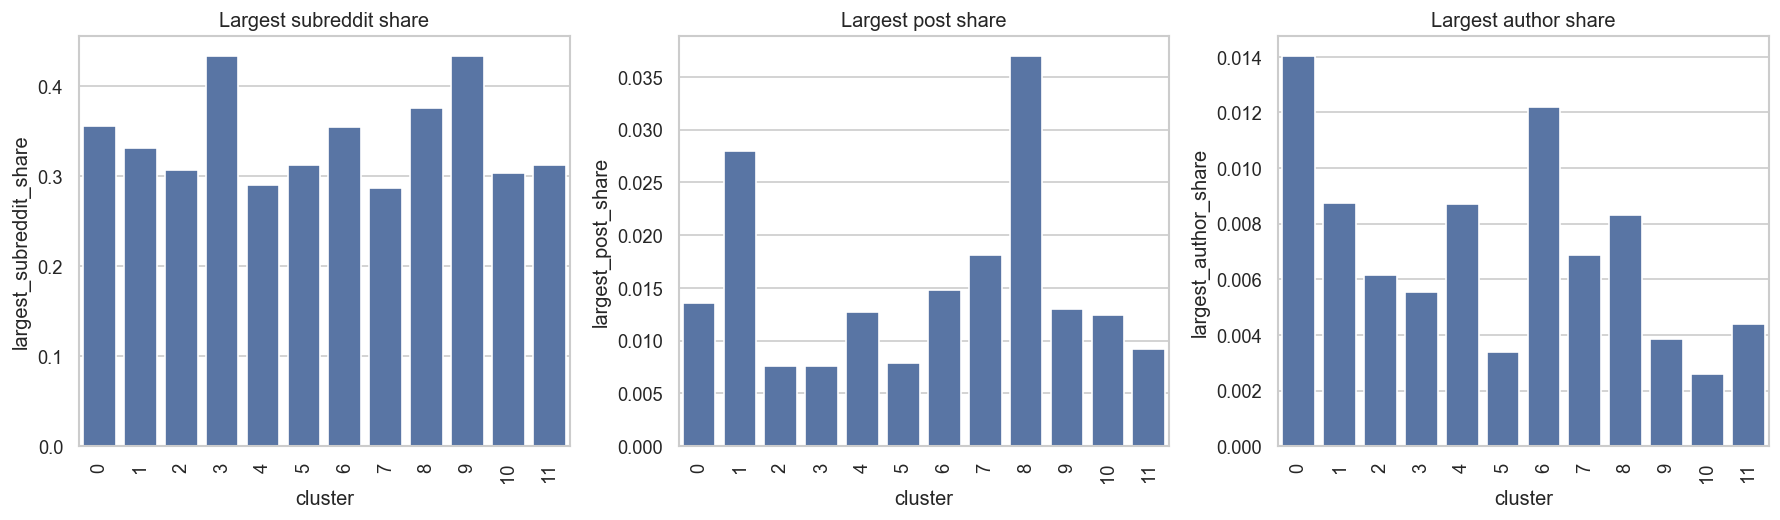

In [13]:
diagnostic_rows = []
for cluster_id, group in model_df.groupby("advanced_cluster"):
    subreddit_share = group["subreddit"].value_counts(normalize=True)
    post_share = group["post_id"].value_counts(normalize=True)
    author_share = group["author_name"].value_counts(normalize=True, dropna=False)
    diagnostic_rows.append({
        "cluster": int(cluster_id),
        "size": len(group),
        "noise": cluster_id == -1,
        "largest_subreddit": subreddit_share.index[0],
        "largest_subreddit_share": subreddit_share.iloc[0],
        "largest_post_share": post_share.iloc[0],
        "largest_author_share": author_share.iloc[0],
        "direct_comment_share": group["direct_comment"].mean(),
    })
dominance_df = pd.DataFrame(diagnostic_rows).sort_values("cluster")
display(dominance_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.barplot(data=dominance_df.loc[~dominance_df["noise"]], x="cluster", y="largest_subreddit_share", ax=axes[0])
axes[0].set_title("Largest subreddit share")
sns.barplot(data=dominance_df.loc[~dominance_df["noise"]], x="cluster", y="largest_post_share", ax=axes[1])
axes[1].set_title("Largest post share")
sns.barplot(data=dominance_df.loc[~dominance_df["noise"]], x="cluster", y="largest_author_share", ax=axes[2])
axes[2].set_title("Largest author share")
for ax in axes:
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

High subreddit concentration may be a real RQ2 result. High single-post or single-author concentration is more likely a sampling artifact and should trigger closer inspection.

社区集中度高可能是真实的 RQ2 结果；单一帖子或单一作者占比过高更可能是抽样伪影，应进一步检查。

## 12. Community topic distributions / 社区主题分布

Compute provisional distributions for both K-means routes at the same k. These are exploratory until the topic review confirms a final method and labels.

advanced_cluster,0,1,2,3,4,5,6,7,8,9,10,11
subreddit,,,,,,,,,,,,
climatechange,16.26,2.49,14.58,6.38,10.50,11.20,2.25,12.41,3.36,4.74,12.45,3.38
climate,7.46,2.15,20.26,4.04,14.67,10.95,2.89,7.06,2.64,10.10,8.03,9.78
energy,0.96,12.07,2.66,31.67,4.72,0.85,8.65,4.12,1.23,26.33,1.57,5.16
Futurology,3.91,9.18,4.70,21.87,8.33,11.09,6.67,6.55,10.56,7.72,4.44,4.97
conspiracy,17.24,2.36,23.29,2.59,6.82,4.95,1.17,10.14,2.23,7.93,11.22,10.05
changemyview,2.61,8.18,10.39,6.48,18.36,17.75,2.76,3.04,8.12,3.89,3.27,15.13


Provisional semantic chi-square: 12009.498485067053
Degrees of freedom: 55
p-value: 0.0
Cramer's V: 0.2916903050193382


advanced_cluster,0,1,2,3,4,5,6,7,8,9,10,11
subreddit,,,,,,,,,,,,
climatechange,19.76,-9.98,3.73,-11.39,-0.14,3.87,-6.17,13.26,-4.22,-11.60,14.75,-11.34
climate,-1.48,-10.93,14.68,-15.99,8.65,3.30,-4.00,-0.42,-6.51,-0.05,3.15,4.09
energy,-17.18,16.70,-19.27,38.33,-12.34,-19.21,15.59,-7.90,-10.95,34.97,-13.80,-7.03
Futurology,-10.05,8.66,-15.33,19.07,-4.72,3.63,8.87,-1.72,18.60,-5.18,-6.27,-7.50
conspiracy,22.12,-10.33,20.54,-18.83,-7.90,-10.06,-9.86,7.45,-7.79,-4.72,11.52,4.76
changemyview,-13.18,5.88,-4.35,-11.19,16.45,18.47,-4.43,-10.67,10.86,-13.43,-9.34,17.02


No noise in the two K-means assignments; HDBSCAN coverage is reported in the model comparison.


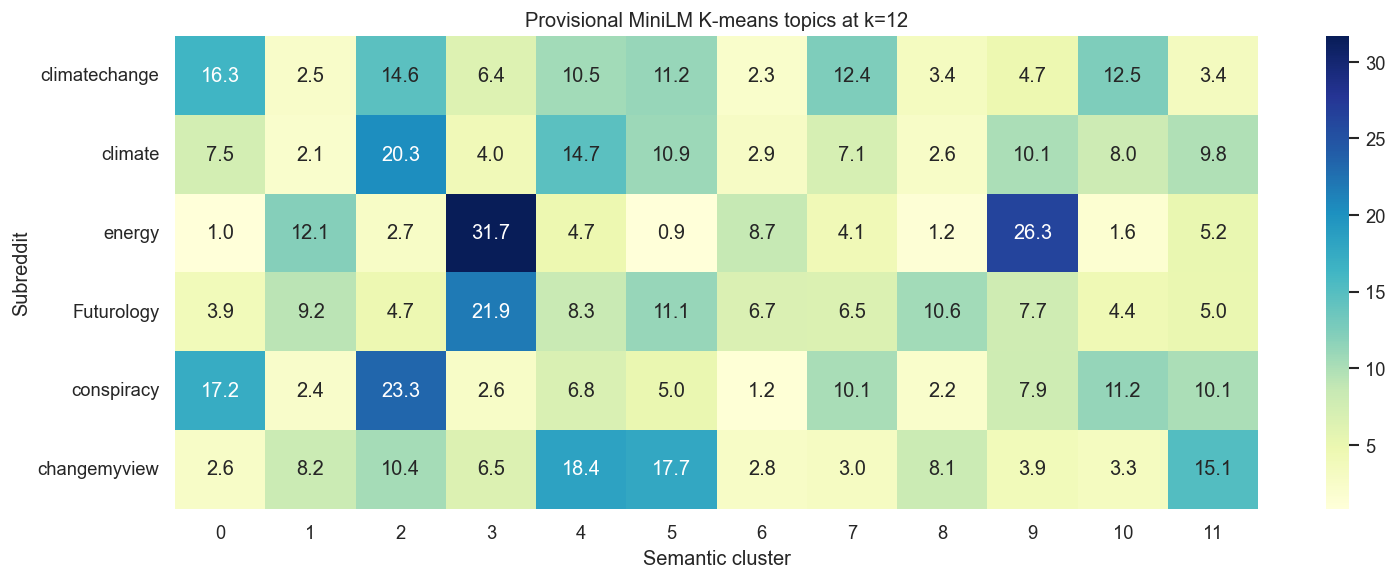

In [14]:
topic_counts = pd.crosstab(model_df["subreddit"], model_df["advanced_cluster"]).reindex(SELECTED_SUBREDDITS)
topic_percentages = topic_counts.div(topic_counts.sum(axis=1), axis=0) * 100
baseline_topic_counts = pd.crosstab(model_df["subreddit"], model_df["baseline_cluster"]).reindex(SELECTED_SUBREDDITS)
baseline_topic_percentages = baseline_topic_counts.div(baseline_topic_counts.sum(axis=1), axis=0) * 100

chi2, p_value, dof, expected = chi2_contingency(topic_counts)
n = topic_counts.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * max(1, min(topic_counts.shape[0] - 1, topic_counts.shape[1] - 1))))
standardized_residuals = (topic_counts - expected) / np.sqrt(expected)
noise_by_subreddit = pd.Series(0.0, index=SELECTED_SUBREDDITS, name="is_noise")

display(topic_percentages.round(2))
print("Provisional semantic chi-square:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)
print("Cramer's V:", cramers_v)
display(pd.DataFrame(standardized_residuals, index=topic_counts.index, columns=topic_counts.columns).round(2))
print("No noise in the two K-means assignments; HDBSCAN coverage is reported in the model comparison.")

plt.figure(figsize=(13, 5))
sns.heatmap(topic_percentages, cmap="YlGnBu", annot=True, fmt=".1f")
plt.title(f"Provisional MiniLM K-means topics at k={PRIMARY_K}")
plt.xlabel("Semantic cluster")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

The heatmap answers RQ2 descriptively. Standardized residuals above about +2 show over-representation and below about −2 show under-representation. Cramér's V reports the strength of association; the p-value alone is not enough for a large sample.

热力图对 RQ2 进行描述性回答。标准化残差约大于 +2 表示过度代表，小于 −2 表示代表不足。Cramér's V 表示关联强度；在大样本中不能只看 p 值。

## 13. Save reviewable outputs / 保存可复核结果

Save the complete gate decision trail, cross-validated gate diagnostics, structured text representations, both k-searches, random and centroid review samples, and second-stage diagnostics in a new output directory. Existing Notebook 09 and 09b outputs remain unchanged.


In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

analysis_df[[
    "comment_id", "post_id", "subreddit", "selection_tier_v2", "post_title", "clean_text",
    "topic_readiness", "topic_readiness_reason", "review_gate_score",
    "reviewed_positive_override", "review_informed_keep",
    "comment_climate_hits", "comment_energy_hits", "comment_impact_hits",
    "comment_argument_hits", "comment_incidental_hits", "context_climate_hit", "context_energy_hit",
]].to_parquet(OUTPUT_DIR / "review_informed_gate_all_eligible.parquet", index=False)

audit_train_df[[
    "comment_id", "relevance_final", "target", "cv_probability", "cv_prediction",
    "title", "comment", "reason_zh",
]].to_csv(OUTPUT_DIR / "review_gate_cv_predictions.csv", index=False, encoding="utf-8-sig")
gate_cv_metrics_df.to_csv(OUTPUT_DIR / "review_gate_cv_metrics.csv", index=False, encoding="utf-8-sig")
gate_threshold_curve_df.to_csv(OUTPUT_DIR / "review_gate_threshold_curve.csv", index=False, encoding="utf-8-sig")
readiness_counts_df.to_csv(OUTPUT_DIR / "review_gate_counts.csv", index=False, encoding="utf-8-sig")

readiness_examples_df = pd.concat([
    group.sample(n=min(3, len(group)), random_state=RANDOM_STATE)
    for _, group in analysis_df.groupby(
        ["subreddit", "topic_readiness", "review_informed_keep"], observed=True
    )
], ignore_index=True)
readiness_examples_df[[
    "comment_id", "subreddit", "post_title", "clean_text", "topic_readiness",
    "topic_readiness_reason", "review_gate_score", "review_informed_keep",
]].to_csv(OUTPUT_DIR / "review_gate_examples.csv", index=False, encoding="utf-8-sig")

model_df.to_parquet(OUTPUT_DIR / "v2_controlled_cluster_assignments.parquet", index=False)
scope_audit.to_csv(OUTPUT_DIR / "v2_scope_audit.csv", encoding="utf-8-sig")
sample_audit.to_csv(OUTPUT_DIR / "v2_model_sample_audit.csv", encoding="utf-8-sig")
cleanup_audit_df.to_csv(OUTPUT_DIR / "topic_text_before_after_examples.csv", index=False, encoding="utf-8-sig")
topic_text_quality_df.to_csv(OUTPUT_DIR / "topic_text_quality.csv", index=False, encoding="utf-8-sig")
baseline_search_df.to_csv(OUTPUT_DIR / "baseline_k_search.csv", index=False, encoding="utf-8-sig")
baseline_terms_df.to_csv(OUTPUT_DIR / "baseline_topic_terms.csv", index=False, encoding="utf-8-sig")
baseline_stability_df.to_csv(OUTPUT_DIR / "baseline_stability.csv", index=False, encoding="utf-8-sig")
advanced_search_df.to_csv(OUTPUT_DIR / "advanced_model_comparison.csv", index=False, encoding="utf-8-sig")
matched_k_comparison_df.to_csv(OUTPUT_DIR / "matched_k_comparison.csv", index=False, encoding="utf-8-sig")
semantic_stability_df.to_csv(OUTPUT_DIR / "semantic_stability.csv", index=False, encoding="utf-8-sig")
advanced_terms_df.to_csv(OUTPUT_DIR / "advanced_topic_terms.csv", index=False, encoding="utf-8-sig")
semantic_cluster_quality_df.to_csv(OUTPUT_DIR / "semantic_cluster_quality.csv", index=False, encoding="utf-8-sig")
semantic_subcluster_diagnostics_df.to_csv(OUTPUT_DIR / "semantic_subcluster_diagnostics.csv", index=False, encoding="utf-8-sig")
advanced_representatives_df.to_csv(OUTPUT_DIR / "advanced_representative_comments.csv", index=False, encoding="utf-8-sig")
topic_review_sample_df.to_csv(OUTPUT_DIR / "topic_review_sample.csv", index=False, encoding="utf-8-sig")
dominance_df.to_csv(OUTPUT_DIR / "advanced_dominance_diagnostics.csv", index=False, encoding="utf-8-sig")
topic_counts.to_csv(OUTPUT_DIR / "advanced_subreddit_topic_counts.csv", encoding="utf-8-sig")
topic_percentages.to_csv(OUTPUT_DIR / "advanced_subreddit_topic_percentages.csv", encoding="utf-8-sig")
baseline_topic_counts.to_csv(OUTPUT_DIR / "baseline_subreddit_topic_counts.csv", encoding="utf-8-sig")
baseline_topic_percentages.to_csv(OUTPUT_DIR / "baseline_subreddit_topic_percentages.csv", encoding="utf-8-sig")
pd.DataFrame(standardized_residuals, index=topic_counts.index, columns=topic_counts.columns).to_csv(
    OUTPUT_DIR / "advanced_standardized_residuals.csv", encoding="utf-8-sig"
)
noise_by_subreddit.to_csv(OUTPUT_DIR / "advanced_noise_by_subreddit.csv", encoding="utf-8-sig")

joblib.dump(gate_pipeline, OUTPUT_DIR / "review_informed_gate.joblib")
joblib.dump(comment_vectorizer, OUTPUT_DIR / "baseline_comment_tfidf_vectorizer.joblib")
joblib.dump(context_vectorizer, OUTPUT_DIR / "baseline_context_tfidf_vectorizer.joblib")
joblib.dump(lsa, OUTPUT_DIR / "baseline_lsa.joblib")
joblib.dump(lsa_normalizer, OUTPUT_DIR / "baseline_lsa_normalizer.joblib")
joblib.dump(baseline_model, OUTPUT_DIR / "baseline_kmeans.joblib")
joblib.dump(umap_model, OUTPUT_DIR / "advanced_umap.joblib")
joblib.dump(advanced_model, OUTPUT_DIR / "selected_advanced_model.joblib")

metadata = {
    "input": str(DATA_PATH), "review_labels": str(REVIEW_PATH), "output": str(OUTPUT_DIR),
    "subreddits": SELECTED_SUBREDDITS,
    "start_date": str(START_DATE.date()),
    "end_date_inclusive": str((END_EXCLUSIVE - pd.Timedelta(days=1)).date()),
    "strict_eligible_comments": int(len(analysis_df)),
    "old_topic_ready_seed": int(analysis_df["topic_readiness"].eq("topic_ready").sum()),
    "review_informed_candidates": int(len(candidate_df)),
    "review_gate_training_rows": int(len(audit_train_df)),
    "review_gate_threshold": GATE_THRESHOLD,
    "review_gate_cv_precision": float(selected_threshold_row["precision"]),
    "review_gate_cv_recall": float(selected_threshold_row["recall"]),
    "topic_filter_version": "review_distilled_union_gate_v1",
    "controlled_comments": int(len(controlled_df)),
    "training_per_subreddit": int(TRAIN_PER_SUBREDDIT),
    "modeling_comments": int(len(model_df)),
    "topic_text_version": "comment_head_tail_plus_separate_context_weighted_v2",
    "comment_embedding_weight": COMMENT_EMBEDDING_WEIGHT,
    "context_embedding_weight": CONTEXT_EMBEDDING_WEIGHT,
    "comment_head_tokens": COMMENT_HEAD_TOKENS,
    "comment_tail_tokens": COMMENT_TAIL_TOKENS,
    "title_tokens": TITLE_TOKENS,
    "body_tokens": BODY_TOKENS,
    "k_search": [K_VALUES[0], K_VALUES[-1]],
    "provisional_comparison_k": PRIMARY_K,
    "baseline_silhouette_leader_k": baseline_silhouette_leader,
    "semantic_silhouette_leader_k": int(
        advanced_search_df.loc[advanced_search_df["method"].eq("semantic_kmeans")]
        .sort_values("silhouette_cosine", ascending=False).iloc[0]["clusters"]
    ),
    "selection_status": "provisional_pending_new_random_sample_review",
    "primary_interpretation_method": "minilm_kmeans",
    "baseline_method": "weighted_comment_context_tfidf_lsa_kmeans",
    "hdbscan_role": "coverage_diagnostic_only",
    "second_stage_role": "diagnostic_candidates_only",
    "embedding_model": EMBEDDING_MODEL_NAME,
    "random_state": RANDOM_STATE,
    "label_limitation": "model-assisted semantic audit, not independent human gold",
}
with open(OUTPUT_DIR / "run_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)
print("Saved outputs to:", OUTPUT_DIR)


Saved outputs to: D:\DM1_project\v2_clustering_outputs_09c_review_informed


Notebook 09c preserves the full decision trail. The old rule status, review-informed score, inclusion decision, full comment, head/tail representation, and post context can all be audited separately.

After running, inspect `review_gate_cv_metrics.csv`, `topic_review_sample.csv`, and `semantic_subcluster_diagnostics.csv`. The next decision is whether the broad semantic clusters should be split; it is no longer whether all `topic_exclude` rows should be discarded.
